# 99. Black-Litterman Baseline

## 논문 구현 (Pyo & Lee, 2018)
변동성 예측 없이 **현재 vol_21d로 직접 분류**한 baseline BL 포트폴리오.

## 전체 흐름
```
[Step 1] 자산 분류 (Baseline: 현재 vol_21d 직접 사용)
   ├── vol_21d 오름차순 정렬
   ├── 하위 30% → 저위험 (long)
   └── 상위 30% → 고위험 (short)

[Step 2] 뷰 포트폴리오 구성
   ├── P: 시총 가중 (저위험 +, 고위험 -)
   ├── Q: Fama-French 3팩터로 추정한 기대수익률 → q = P·r̂
   └── Ω: He-Litterman 공식 (τ·P·Σ·P^T)

[Step 3] BL 사후 (Sherman-Woodbury)
   └── μ_BL = Π + τΣP^T[P(τΣ)P^T + Ω]^{-1}(q - PΠ)

[Step 4] 포트폴리오 최적화
   └── min (λ/2)w^T Σ w - w^T μ_BL
       s.t. Σw=1, w≥0
```

## 비교 대상
- **BL (Baseline)**: 현재 vol_21d 분류 → BL 최적화
- **CAPM 균형**: BL 없이 μ=Π 그대로 최적화
- **S&P 500 (SPY)**: 시장 지수

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import io, re, zipfile, requests
import warnings
import platform
from pathlib import Path
from sklearn.covariance import LedoitWolf
from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs' / '99_baseline'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 파라미터 ────────────────────────────────────────────────
TRAIN_WINDOW = 60    # 공분산·FF3 추정 윈도우 (개월)
TAU          = 0.1
PCT_GROUP    = 0.30
START_PRED   = '2009-01-01'
LAM_FIXED    = 2.5   # None이면 SPY 기반 동적 계산, 숫자면 고정 (He & Litterman 1999)

# ── 데이터 로드 ──────────────────────────────────────────────
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])

all_dates  = panel.index.get_level_values('date').unique().sort_values()
pred_dates = all_dates[all_dates >= START_PRED]

print(f'패널: {panel.shape}')
print(f'컬럼: {list(panel.columns)}')
print(f'예측 기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'LAM_FIXED = {LAM_FIXED}  (None이면 동적 계산)')

패널: (108180, 11)
컬럼: ['vol_21d', 'vol_60d', 'vol_252d', 'beta_252d', 'close', 'log_mcap', 'fwd_ret_1m', 'gics_sector', 'spy_ret', 'rf_1m', 'ret_1m']
예측 기간: 2009-01-31 ~ 2025-12-31 (204개월)
LAM_FIXED = 2.5  (None이면 동적 계산)


In [2]:
# ── FF3 팩터 로드 (02에서 저장한 파일 재사용) ────────────────
FF3_PATH = DATA_DIR / 'ff3_monthly.csv'

def download_ff3():
    url = ('https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/'
           'F-F_Research_Data_Factors_CSV.zip')
    resp = requests.get(url, timeout=60)
    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        raw = zf.read(zf.namelist()[0]).decode('utf-8', errors='ignore')
    lines = raw.splitlines()
    start = next(i for i, l in enumerate(lines) if re.match(r'^\s*\d{6}\s*,', l))
    end   = next((i for i in range(start, len(lines))
                  if not re.match(r'^\s*\d{6}\s*,', lines[i])), len(lines))
    df = pd.read_csv(io.StringIO('\n'.join(lines[start-1:end])))
    df.columns = [c.strip() for c in df.columns]
    date_col = df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col].astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
    df = df.rename(columns={date_col: 'date', 'Mkt-RF': 'mkt_rf',
                             'SMB': 'smb', 'HML': 'hml', 'RF': 'rf'})
    return df.set_index('date').astype(float) / 100.0

if FF3_PATH.exists():
    ff3 = pd.read_csv(FF3_PATH, index_col='date', parse_dates=True)
    print(f'FF3 로드: {ff3.shape}')
else:
    print('FF3 다운로드 중...')
    ff3 = download_ff3()
    ff3.to_csv(FF3_PATH)
    print(f'FF3 저장: {ff3.shape}')

print(ff3.tail(3))

FF3 로드: (1196, 4)
            mkt_rf     smb     hml      rf
date                                      
2025-12-31 -0.0036 -0.0106  0.0242  0.0034
2026-01-31  0.0102  0.0220  0.0372  0.0030
2026-02-28 -0.0117  0.0014  0.0283  0.0028


In [3]:
# ── BL 구성 함수들 ───────────────────────────────────────────

def compute_sigma(ret_matrix):
    lw = LedoitWolf().fit(ret_matrix.values)
    return pd.DataFrame(lw.covariance_,
                        index=ret_matrix.columns,
                        columns=ret_matrix.columns)


def compute_pi(Sigma, w_mkt, spy_excess_ret, sigma2_mkt):
    if LAM_FIXED is not None:
        lam = LAM_FIXED
    else:
        lam = spy_excess_ret / sigma2_mkt if sigma2_mkt > 0 else 2.5
        lam = np.clip(lam, 0.5, 10.0)
    return lam * Sigma @ w_mkt, lam


def build_P(vol_series, mcap_series, pct=0.30):
    n_group    = max(1, int(len(vol_series) * pct))
    sorted_idx = vol_series.sort_values().index
    low_risk   = sorted_idx[:n_group]
    high_risk  = sorted_idx[-n_group:]
    P = pd.Series(0.0, index=vol_series.index)
    low_m  = mcap_series[low_risk]
    high_m = mcap_series[high_risk]
    P[low_risk]  =  low_m  / low_m.sum()
    P[high_risk] = -high_m / high_m.sum()
    return P


def compute_Q_hist(P, ret_matrix):
    p_vec = P.reindex(ret_matrix.columns).fillna(0).values
    return float((ret_matrix.values @ p_vec).mean())


def compute_Q_ff3(P, ret_matrix, ff3_train, rf_train):
    view_tickers = [t for t in P[P != 0].index if t in ret_matrix.columns]
    if not view_tickers:
        return 0.0
    ff3_aligned = ff3_train.reindex(ret_matrix.index).dropna()
    rf_aligned  = rf_train.reindex(ff3_aligned.index).fillna(0)
    n = len(ff3_aligned)
    if n < 24:
        return 0.0
    X      = np.column_stack([np.ones(n), ff3_aligned[['mkt_rf', 'smb', 'hml']].values])
    X_next = np.array([1.0] + ff3_aligned[['mkt_rf', 'smb', 'hml']].tail(12).mean().tolist())
    rf_next = float(rf_train.iloc[-1]) if len(rf_train) > 0 else 0.0
    Y    = (ret_matrix[view_tickers].reindex(ff3_aligned.index).fillna(0).values
            - rf_aligned.values.reshape(-1, 1))
    coef = np.linalg.lstsq(X, Y, rcond=None)[0]
    r_hat_view = X_next @ coef + rf_next
    r_hat = pd.Series(0.0, index=ret_matrix.columns)
    for j, t in enumerate(view_tickers):
        r_hat[t] = r_hat_view[j]
    return float(P.reindex(ret_matrix.columns).fillna(0) @ r_hat)


def compute_omega(P, Sigma, tau):
    p     = P.values
    omega = float(tau * p @ Sigma.values @ p)
    return max(omega, 1e-8)


def black_litterman(pi, Sigma, P, q, omega, tau):
    p    = P.values
    pi_v = pi.values
    tSig = tau * Sigma.values
    M      = float(p @ tSig @ p) + omega
    diff   = q - float(p @ pi_v)
    adjust = tSig @ p * (diff / M)
    return pd.Series(pi_v + adjust, index=pi.index)


def optimize_portfolio(mu_BL, Sigma, lam):
    n   = len(mu_BL)
    mu  = mu_BL.values
    Sig = Sigma.values
    def obj(w): return 0.5 * lam * w @ Sig @ w - w @ mu
    def jac(w): return lam * Sig @ w - mu
    res = minimize(obj, np.ones(n)/n, jac=jac, method='SLSQP',
                   bounds=[(0, 1)]*n,
                   constraints=[{'type': 'eq', 'fun': lambda w: w.sum()-1}])
    w = res.x if res.success else np.ones(n)/n
    return pd.Series(w, index=mu_BL.index)


print('BL 함수 정의 완료')

BL 함수 정의 완료


In [4]:
# ── 루프 밖: 한 번만 계산 ────────────────────────────────────
ret_pivot  = panel['ret_1m'].unstack('ticker')
spy_series = panel['spy_ret'].groupby(level='date').first()
rf_series  = panel['rf_1m'].groupby(level='date').first()

Q_FIXED = 0.003  # 월 0.3% = 연 3.6%
print(f'Q_FIXED = {Q_FIXED}  (월 {Q_FIXED*100:.1f}%  |  연 {Q_FIXED*12*100:.1f}%)')

# ── Walk-forward (구성 진단 로깅 포함) ────────────────────────
bl_returns, capm_returns, spy_returns, error_log = [], [], [], []
composition_log = []
print(f'Walk-forward: {pred_dates[0].date()} ~ {pred_dates[-1].date()}')

for i, pred_date in enumerate(pred_dates):
    if (i + 1) % 12 == 0:
        print(f'  {pred_date.date()} ({i+1}/{len(pred_dates)})')

    try:
        month_df = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_df) < 30:
            continue
        universe = month_df.index.tolist()

        idx = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]

        thresh    = int(len(train_dates) * 0.7)
        ret_slice = (ret_pivot.reindex(index=train_dates, columns=universe)
                            .dropna(axis=1, thresh=thresh)
                            .fillna(0))
        valid_tix = ret_slice.columns.tolist()
        if len(valid_tix) < 20:
            continue

        month_df = month_df.reindex(valid_tix)
        Sigma    = compute_sigma(ret_slice)

        mcap  = np.exp(month_df['log_mcap'])
        w_mkt = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)

        spy_s      = spy_series.reindex(train_dates)
        rf_s       = rf_series.reindex(train_dates)
        spy_excess = (spy_s - rf_s).mean()
        sigma2_mkt = spy_s.var()

        pi, lam = compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt)

        P = build_P(month_df['vol_21d'], mcap, pct=PCT_GROUP)
        P = P.reindex(valid_tix).fillna(0)

        q     = Q_FIXED
        omega = compute_omega(P, Sigma, TAU)
        mu_BL = black_litterman(pi, Sigma, P, q, omega, TAU)

        w_bl   = optimize_portfolio(mu_BL, Sigma, lam)
        w_capm = optimize_portfolio(pi,    Sigma, lam)

        # ── 다음달 수익률 적용 ─────────────────────────────────
        actual_ret = month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0)
        next_date  = all_dates[idx + 1] if idx + 1 < len(all_dates) else None
        r_spy      = float(spy_series.get(next_date, np.nan)) if next_date is not None else np.nan

        bl_returns.append(  {'date': pred_date, 'ret': float(w_bl   @ actual_ret)})
        capm_returns.append({'date': pred_date, 'ret': float(w_capm @ actual_ret)})
        spy_returns.append( {'date': pred_date, 'ret': r_spy})

        # ── 구성 진단 로깅 ─────────────────────────────────────
        n_group       = max(1, int(len(valid_tix) * PCT_GROUP))
        sorted_by_vol = month_df['vol_21d'].sort_values()
        low_risk_tix  = sorted_by_vol.index[:n_group].tolist()
        high_risk_tix = sorted_by_vol.index[-n_group:].tolist()
        vol           = month_df['vol_21d']

        composition_log.append({
            'date'            : pred_date,
            'n_stocks'        : len(valid_tix),
            'bl_eff_n'        : 1.0 / float((w_bl**2).sum()),
            'bl_hhi'          : float((w_bl**2).sum()),
            'bl_top10_share'  : float(w_bl.nlargest(10).sum()),
            'bl_avg_vol'      : float((w_bl * vol).sum()),
            'bl_low_weight'   : float(w_bl[low_risk_tix].sum()),
            'bl_high_weight'  : float(w_bl[high_risk_tix].sum()),
            'bl_top1_weight'  : float(w_bl.max()),
            'bl_top1_ticker'  : w_bl.idxmax(),
            'capm_eff_n'      : 1.0 / float((w_capm**2).sum()),
            'capm_top10_share': float(w_capm.nlargest(10).sum()),
            'capm_avg_vol'    : float((w_capm * vol).sum()),
            'capm_low_weight' : float(w_capm[low_risk_tix].sum()),
            'capm_high_weight': float(w_capm[high_risk_tix].sum()),
        })

    except Exception as e:
        error_log.append({'date': pred_date, 'error': str(e)})
        if len(error_log) <= 3:
            print(f'  [에러] {pred_date.date()}: {e}')

print(f'\n성공: {len(bl_returns)}개월 / {len(pred_dates)}개월')
print(f'에러: {len(error_log)}개월')

if bl_returns:
    bl_ret   = pd.DataFrame(bl_returns).set_index('date')['ret']
    capm_ret = pd.DataFrame(capm_returns).set_index('date')['ret']
    spy_ret  = pd.DataFrame(spy_returns).set_index('date')['ret']
    comp     = pd.DataFrame(composition_log).set_index('date')
    comp.to_csv(DATA_DIR / 'portfolio_composition_99.csv')
    print('DataFrame 생성 완료')
else:
    print('결과 없음 — 첫 에러:', error_log[0] if error_log else '에러 없음')

Q_FIXED = 0.003  (월 0.3%  |  연 3.6%)
Walk-forward: 2009-01-31 ~ 2025-12-31


  2009-12-31 (12/204)
  2010-12-31 (24/204)
  2011-12-31 (36/204)
  2012-12-31 (48/204)
  2013-12-31 (60/204)
  2014-12-31 (72/204)
  2015-12-31 (84/204)
  2016-12-31 (96/204)
  2017-12-31 (108/204)
  2018-12-31 (120/204)
  2019-12-31 (132/204)
  2020-12-31 (144/204)
  2021-12-31 (156/204)
  2022-12-31 (168/204)
  2023-12-31 (180/204)
  2024-12-31 (192/204)
  2025-12-31 (204/204)

성공: 204개월 / 204개월
에러: 0개월
DataFrame 생성 완료


In [5]:
# ── 성과 분석 ────────────────────────────────────────────────
ANN = np.sqrt(12)

rf_monthly = panel['rf_1m'].groupby(level='date').first().reindex(bl_ret.index).fillna(0)

def performance(ret, rf, label):
    excess   = ret - rf
    ann_ret  = ret.mean() * 12
    ann_vol  = ret.std() * ANN
    sharpe   = excess.mean() / excess.std() * ANN
    cum_ret  = (1 + ret).prod() - 1
    # MDD
    cum      = (1 + ret).cumprod()
    peak     = cum.cummax()
    drawdown = (cum - peak) / peak
    mdd      = drawdown.min()
    print(f'[{label}]')
    print(f'  연환산 수익률: {ann_ret:.2%}')
    print(f'  연환산 변동성: {ann_vol:.2%}')
    print(f'  Sharpe Ratio:  {sharpe:.3f}')
    print(f'  누적 수익률:   {cum_ret:.2%}')
    print(f'  MDD:           {mdd:.2%}')
    return {'label': label, 'ann_ret': ann_ret, 'ann_vol': ann_vol,
            'sharpe': sharpe, 'cum_ret': cum_ret, 'mdd': mdd}

print('=' * 55)
print('포트폴리오 성과 비교')
print('=' * 55)
stats = []
for ret, label in [(bl_ret, 'BL Baseline'), (capm_ret, 'CAPM 균형'), (spy_ret, 'S&P 500')]:
    stats.append(performance(ret, rf_monthly, label))
    print()

포트폴리오 성과 비교
[BL Baseline]
  연환산 수익률: 15.00%
  연환산 변동성: 11.80%
  Sharpe Ratio:  1.157
  누적 수익률:   1021.86%
  MDD:           -11.80%

[CAPM 균형]
  연환산 수익률: 16.14%
  연환산 변동성: 16.14%
  Sharpe Ratio:  0.919
  누적 수익률:   1124.85%
  MDD:           -22.77%

[S&P 500]
  연환산 수익률: 15.46%
  연환산 변동성: 14.72%
  Sharpe Ratio:  0.964
  누적 수익률:   1022.71%
  MDD:           -23.93%



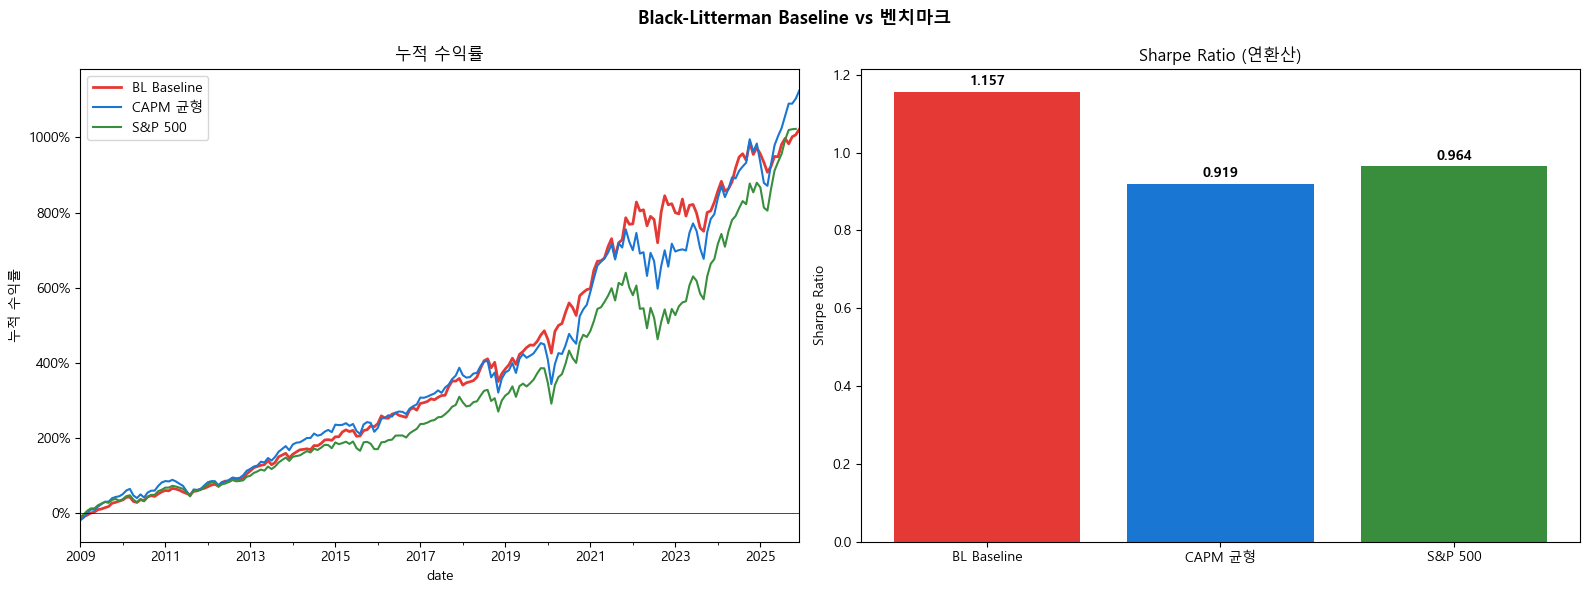

결과 저장 완료


In [6]:
# ── 시각화 ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Black-Litterman Baseline vs 벤치마크', fontsize=13, fontweight='bold')

# ① 누적 수익률
ax = axes[0]
for ret, label, color, lw in [
    (bl_ret,   'BL Baseline', '#E53935', 2.0),
    (capm_ret, 'CAPM 균형',   '#1976D2', 1.5),
    (spy_ret,  'S&P 500',     '#388E3C', 1.5),
]:
    cum = (1 + ret).cumprod() - 1
    cum.plot(ax=ax, label=label, color=color, linewidth=lw)
ax.set_title('누적 수익률')
ax.set_ylabel('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)

# ② Sharpe Ratio 막대
ax = axes[1]
labels  = [s['label']  for s in stats]
sharpes = [s['sharpe'] for s in stats]
colors  = ['#E53935', '#1976D2', '#388E3C']
bars    = ax.bar(labels, sharpes, color=colors)
ax.set_title('Sharpe Ratio (연환산)')
ax.set_ylabel('Sharpe Ratio')
ax.axhline(0, color='black', linewidth=0.5)
for bar, val in zip(bars, sharpes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / 'bl_baseline_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# 결과 저장
result_df = pd.DataFrame({'bl': bl_ret, 'capm': capm_ret, 'spy': spy_ret})
result_df.to_csv(DATA_DIR / 'bl_baseline_returns.csv')
print('결과 저장 완료')

BL Baseline vs 단순 저변동성 포트폴리오

[BL Baseline       (vol_21d + BL 최적화)]
  Sharpe: 1.157  연수익: 15.00%  변동성: 11.80%  MDD: -11.80%

[단순 저변동성     (vol_21d 하위30% 시총가중)]
  Sharpe: 1.075  연수익: 14.48%  변동성: 12.22%  MDD: -14.31%

[CAPM 균형         (전체 시총가중)]
  Sharpe: 0.919  연수익: 16.14%  변동성: 16.14%  MDD: -22.77%

[S&P 500]
  Sharpe: 0.964  연수익: 15.46%  변동성: 14.72%  MDD: -23.93%


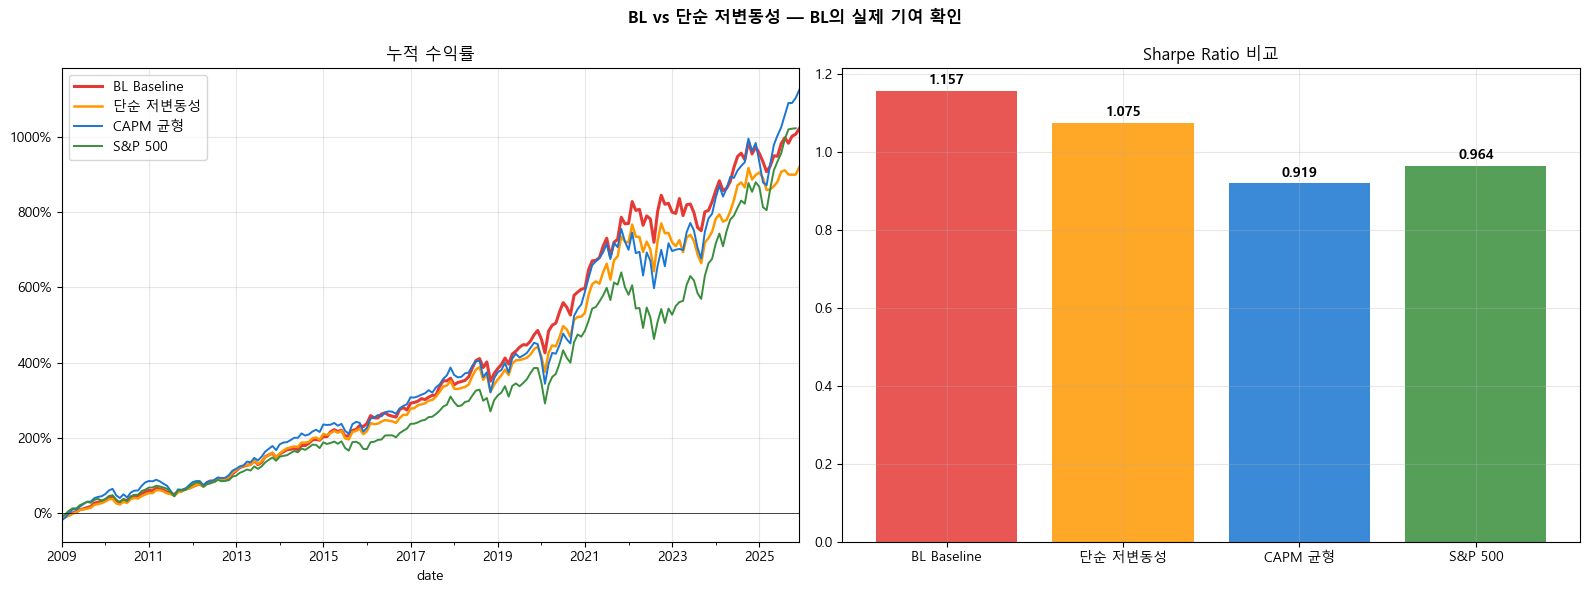

In [7]:
# ── 단순 저변동성 포트폴리오 (naive low-vol benchmark) ──────────
# BL 없이 그냥 vol_21d 하위 30% 시총가중 보유
# → BL이 기여하는지 vs 저변동성 선택 자체의 효과인지 분리

naive_lowvol_returns = []

for i, pred_date in enumerate(pred_dates):
    try:
        month_df = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'fwd_ret_1m'])
        if len(month_df) < 30:
            continue

        n_group   = max(1, int(len(month_df) * PCT_GROUP))
        low_tix   = month_df['vol_21d'].sort_values().index[:n_group]
        mcap_low  = np.exp(month_df.loc[low_tix, 'log_mcap'])
        w_naive   = mcap_low / mcap_low.sum()
        ret_naive = float(w_naive @ month_df.loc[low_tix, 'fwd_ret_1m'].fillna(0))
        naive_lowvol_returns.append({'date': pred_date, 'ret': ret_naive})
    except:
        pass

naive_ret = pd.DataFrame(naive_lowvol_returns).set_index('date')['ret']

# ── 성과 비교 ─────────────────────────────────────────────────
print('=' * 60)
print('BL Baseline vs 단순 저변동성 포트폴리오')
print('=' * 60)
rf_m = panel['rf_1m'].groupby(level='date').first().reindex(bl_ret.index).fillna(0)

for ret, label in [
    (bl_ret,   'BL Baseline       (vol_21d + BL 최적화)'),
    (naive_ret,'단순 저변동성     (vol_21d 하위30% 시총가중)'),
    (capm_ret, 'CAPM 균형         (전체 시총가중)'),
    (spy_ret,  'S&P 500'),
]:
    rf   = rf_m.reindex(ret.index).fillna(0)
    exc  = ret - rf
    sr   = exc.mean() / exc.std() * np.sqrt(12)
    ar   = ret.mean() * 12
    av   = ret.std() * np.sqrt(12)
    cum  = (1 + ret).cumprod()
    mdd  = ((cum - cum.cummax()) / cum.cummax()).min()
    print(f'\n[{label}]')
    print(f'  Sharpe: {sr:.3f}  연수익: {ar:.2%}  변동성: {av:.2%}  MDD: {mdd:.2%}')

# ── 시각화 ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('BL vs 단순 저변동성 — BL의 실제 기여 확인', fontweight='bold')

portfolios_cmp = [
    (bl_ret,    'BL Baseline',    '#E53935', 2.2),
    (naive_ret, '단순 저변동성',  '#FF9800', 1.8),
    (capm_ret,  'CAPM 균형',      '#1976D2', 1.4),
    (spy_ret,   'S&P 500',        '#388E3C', 1.4),
]

ax = axes[0]
for ret, label, color, lw in portfolios_cmp:
    (1 + ret).cumprod().sub(1).plot(ax=ax, label=label, color=color, linewidth=lw)
ax.set_title('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
ax.axhline(0, color='k', lw=0.5)
ax.grid(True, alpha=0.3)

ax = axes[1]
labels_bar  = [l for _, l, _, _ in portfolios_cmp]
sharpes_bar = []
for ret, label, color, lw in portfolios_cmp:
    rf  = rf_m.reindex(ret.index).fillna(0)
    exc = ret - rf
    sharpes_bar.append(exc.mean() / exc.std() * np.sqrt(12))
colors_bar = [c for _, _, c, _ in portfolios_cmp]
bars = ax.bar(labels_bar, sharpes_bar, color=colors_bar, alpha=0.85)
for bar, val in zip(bars, sharpes_bar):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Sharpe Ratio 비교')
ax.axhline(0, color='k', lw=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'bl_vs_naive_lowvol.png', dpi=150, bbox_inches='tight')
plt.show()

Prior 비교: 시총가중 vs 1/N 동일가중

[BL (시총가중 prior)    ]
  Sharpe: 1.157  연수익: 15.00%  변동성: 11.80%  MDD: -11.80%

[BL (1/N 동일가중 prior)]
  Sharpe: 1.206  연수익: 16.25%  변동성: 12.35%  MDD: -12.87%

[단순 저변동성 (BL 없음)]
  Sharpe: 1.075  연수익: 14.48%  변동성: 12.22%  MDD: -14.31%

[S&P 500               ]
  Sharpe: 0.964  연수익: 15.46%  변동성: 14.72%  MDD: -23.93%


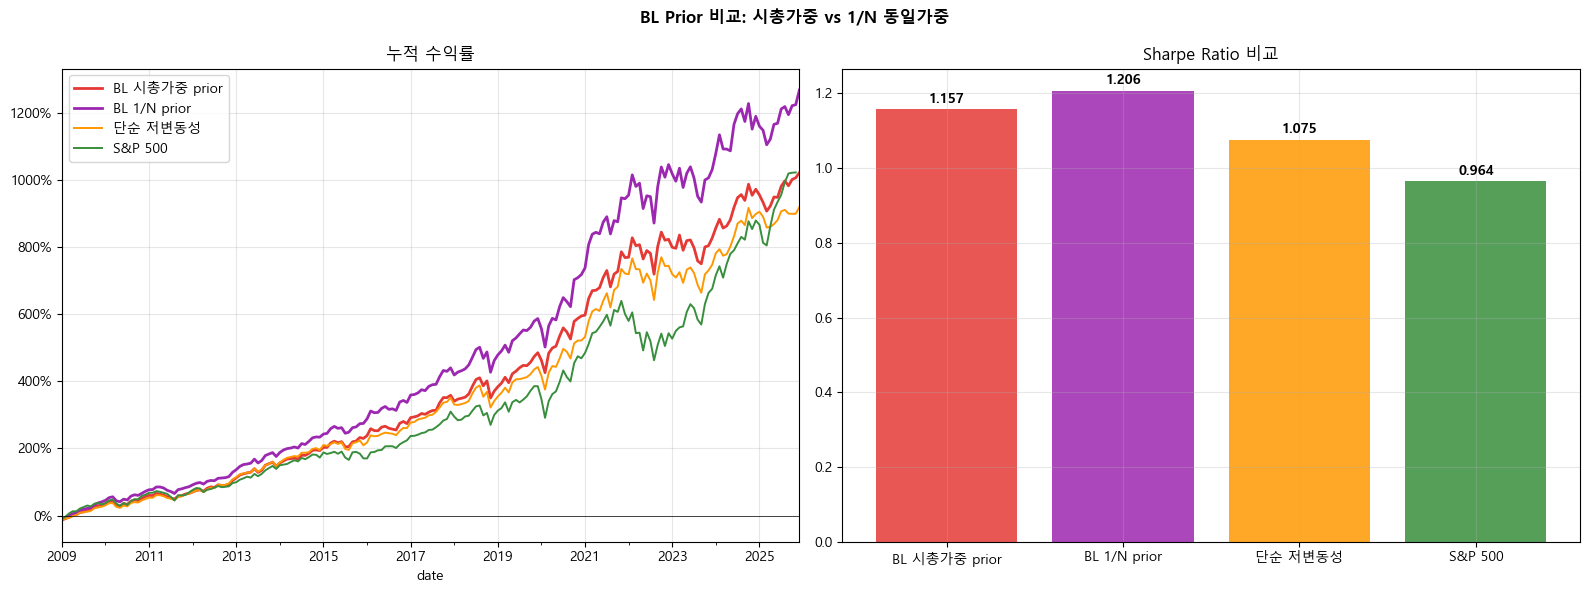

In [8]:
# ── Prior: 1/N (동일가중) vs 시총가중 비교 ───────────────────
# BL prior π = λΣw 에서 w를 시총 대신 동일가중으로 바꾼 버전

bl_eq_returns = []

for i, pred_date in enumerate(pred_dates):
    try:
        month_df = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_df) < 30:
            continue
        universe = month_df.index.tolist()

        idx = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]

        thresh    = int(len(train_dates) * 0.7)
        ret_slice = (ret_pivot.reindex(index=train_dates, columns=universe)
                              .dropna(axis=1, thresh=thresh)
                              .fillna(0))
        valid_tix = ret_slice.columns.tolist()
        if len(valid_tix) < 20:
            continue

        month_df = month_df.reindex(valid_tix)
        Sigma    = compute_sigma(ret_slice)

        # 1/N prior
        w_eq = pd.Series(1.0 / len(valid_tix), index=valid_tix)

        spy_s      = spy_series.reindex(train_dates)
        rf_s       = rf_series.reindex(train_dates)
        spy_excess = (spy_s - rf_s).mean()
        sigma2_mkt = spy_s.var()

        pi_eq, lam = compute_pi(Sigma, w_eq, spy_excess, sigma2_mkt)

        mcap  = np.exp(month_df['log_mcap'])
        P     = build_P(month_df['vol_21d'], mcap, pct=PCT_GROUP)
        P     = P.reindex(valid_tix).fillna(0)

        omega    = compute_omega(P, Sigma, TAU)
        mu_BL_eq = black_litterman(pi_eq, Sigma, P, Q_FIXED, omega, TAU)
        w_bl_eq  = optimize_portfolio(mu_BL_eq, Sigma, lam)

        actual_ret = month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0)
        bl_eq_returns.append({'date': pred_date, 'ret': float(w_bl_eq @ actual_ret)})

    except:
        pass

bl_eq_ret = pd.DataFrame(bl_eq_returns).set_index('date')['ret']

# ── 성과 비교 ─────────────────────────────────────────────────
print('=' * 60)
print('Prior 비교: 시총가중 vs 1/N 동일가중')
print('=' * 60)

for ret, label in [
    (bl_ret,    'BL (시총가중 prior)    '),
    (bl_eq_ret, 'BL (1/N 동일가중 prior)'),
    (naive_ret, '단순 저변동성 (BL 없음)'),
    (spy_ret,   'S&P 500               '),
]:
    rf  = rf_m.reindex(ret.index).fillna(0)
    exc = ret - rf
    sr  = exc.mean() / exc.std() * np.sqrt(12)
    ar  = ret.mean() * 12
    av  = ret.std() * np.sqrt(12)
    cum = (1 + ret).cumprod()
    mdd = ((cum - cum.cummax()) / cum.cummax()).min()
    print(f'\n[{label}]')
    print(f'  Sharpe: {sr:.3f}  연수익: {ar:.2%}  변동성: {av:.2%}  MDD: {mdd:.2%}')

# ── 시각화 ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('BL Prior 비교: 시총가중 vs 1/N 동일가중', fontweight='bold')

portfolios_prior = [
    (bl_ret,    'BL 시총가중 prior', '#E53935', 2.0),
    (bl_eq_ret, 'BL 1/N prior',      '#9C27B0', 2.0),
    (naive_ret, '단순 저변동성',     '#FF9800', 1.4),
    (spy_ret,   'S&P 500',           '#388E3C', 1.4),
]

ax = axes[0]
for ret, label, color, lw in portfolios_prior:
    (1 + ret).cumprod().sub(1).plot(ax=ax, label=label, color=color, linewidth=lw)
ax.set_title('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
ax.axhline(0, color='k', lw=0.5)
ax.grid(True, alpha=0.3)

ax = axes[1]
labels_p, sharpes_p, colors_p = [], [], []
for ret, label, color, lw in portfolios_prior:
    rf  = rf_m.reindex(ret.index).fillna(0)
    exc = ret - rf
    labels_p.append(label)
    sharpes_p.append(exc.mean() / exc.std() * np.sqrt(12))
    colors_p.append(color)
bars = ax.bar(labels_p, sharpes_p, color=colors_p, alpha=0.85)
for bar, val in zip(bars, sharpes_p):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Sharpe Ratio 비교')
ax.axhline(0, color='k', lw=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'bl_prior_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

전략 계층별 비교: 선택 효과 vs 가중 방식 vs BL 기여

[BL (시총 prior)]
  Sharpe: 1.157  연수익: 15.00%  변동성: 11.80%  MDD: -11.80%

[BL (1/N prior)]
  Sharpe: 1.206  연수익: 16.25%  변동성: 12.35%  MDD: -12.87%

[1/N 등가중 (BL 없음)]
  Sharpe: 1.057  연수익: 14.53%  변동성: 12.48%  MDD: -15.22%

[시총가중 (BL 없음)]
  Sharpe: 1.075  연수익: 14.48%  변동성: 12.22%  MDD: -14.31%

[S&P 500]
  Sharpe: 0.964  연수익: 15.46%  변동성: 14.72%  MDD: -23.93%


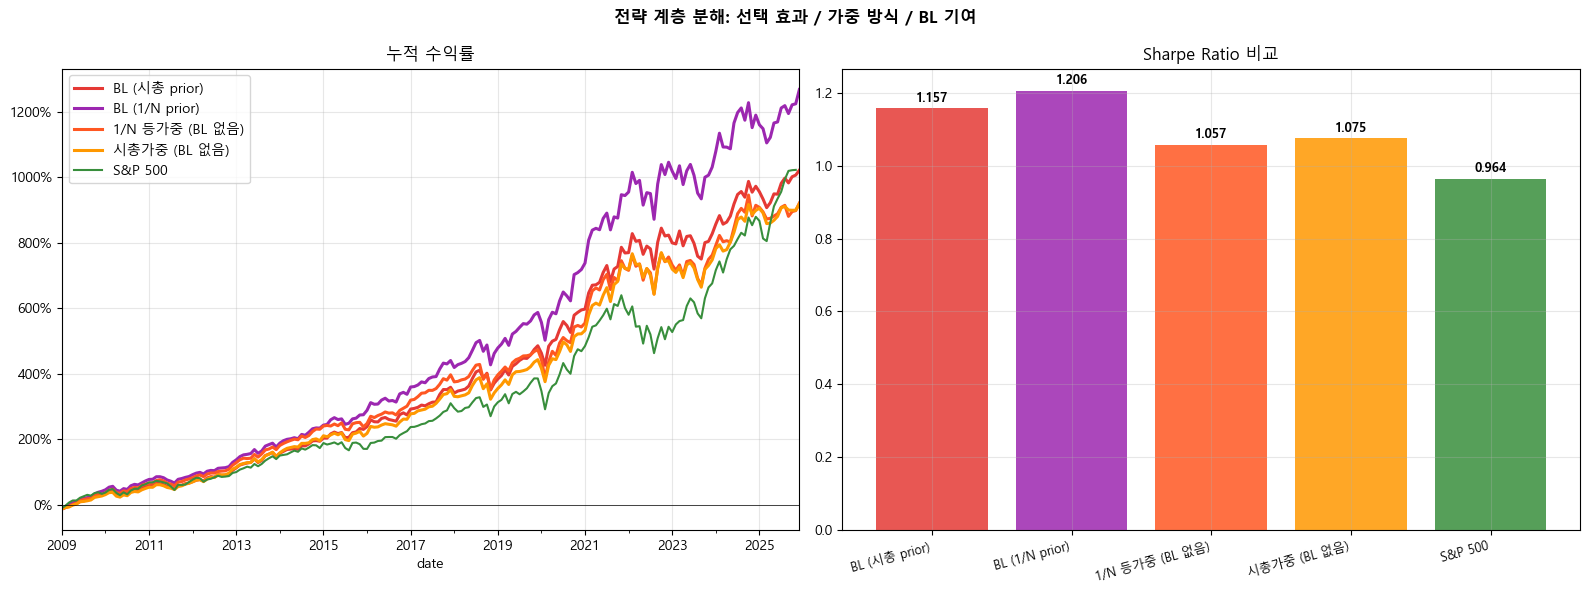

저장 완료: bl_strategy_decomposition.png


In [10]:
# ── 1/N 등가중 포트폴리오 (BL 없음, 저변동성 유니버스) ────────
# naive_ret: 저변동성 하위30% + 시총가중 (BL 없음)   → vol selection 효과
# eq_ret:    저변동성 하위30% + 동일가중 (BL 없음)   → 1/N 자체 효과
# bl_eq_ret: 저변동성 뷰 + 1/N prior + BL 최적화    → BL 추가 기여

eq_lowvol_returns = []

for pred_date in pred_dates:
    try:
        month_df = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'fwd_ret_1m'])
        if len(month_df) < 30:
            continue
        n_group  = max(1, int(len(month_df) * PCT_GROUP))
        low_tix  = month_df['vol_21d'].sort_values().index[:n_group]
        w_eq     = pd.Series(1.0 / len(low_tix), index=low_tix)
        ret_eq   = float(w_eq @ month_df.loc[low_tix, 'fwd_ret_1m'].fillna(0))
        eq_lowvol_returns.append({'date': pred_date, 'ret': ret_eq})
    except:
        pass

eq_ret = pd.DataFrame(eq_lowvol_returns).set_index('date')['ret']

# ── 전체 비교 ─────────────────────────────────────────────────
print('=' * 65)
print('전략 계층별 비교: 선택 효과 vs 가중 방식 vs BL 기여')
print('=' * 65)

all_cmp = [
    (bl_ret,    'BL (시총 prior)',         '#E53935'),
    (bl_eq_ret, 'BL (1/N prior)',          '#9C27B0'),
    (eq_ret,    '1/N 등가중 (BL 없음)',    '#FF5722'),
    (naive_ret, '시총가중 (BL 없음)',      '#FF9800'),
    (spy_ret,   'S&P 500',                 '#388E3C'),
]

for ret, label, _ in all_cmp:
    rf  = rf_m.reindex(ret.index).fillna(0)
    exc = ret - rf
    sr  = exc.mean() / exc.std() * np.sqrt(12)
    ar  = ret.mean() * 12
    av  = ret.std() * np.sqrt(12)
    cum = (1 + ret).cumprod()
    mdd = ((cum - cum.cummax()) / cum.cummax()).min()
    print(f'\n[{label}]')
    print(f'  Sharpe: {sr:.3f}  연수익: {ar:.2%}  변동성: {av:.2%}  MDD: {mdd:.2%}')

# ── 시각화 ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('전략 계층 분해: 선택 효과 / 가중 방식 / BL 기여', fontweight='bold')

ax = axes[0]
for ret, label, color in all_cmp:
    lw = 2.2 if 'BL' in label else 1.5
    (1 + ret).cumprod().sub(1).plot(ax=ax, label=label, color=color, linewidth=lw)
ax.set_title('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
ax.axhline(0, color='k', lw=0.5)
ax.grid(True, alpha=0.3)

ax = axes[1]
labels_b, sharpes_b, colors_b = [], [], []
for ret, label, color in all_cmp:
    rf  = rf_m.reindex(ret.index).fillna(0)
    exc = ret - rf
    labels_b.append(label)
    sharpes_b.append(exc.mean() / exc.std() * np.sqrt(12))
    colors_b.append(color)
bars = ax.bar(labels_b, sharpes_b, color=colors_b, alpha=0.85)
for bar, val in zip(bars, sharpes_b):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Sharpe Ratio 비교')
ax.set_xticklabels(labels_b, rotation=15, ha='right', fontsize=9)
ax.axhline(0, color='k', lw=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'bl_strategy_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: bl_strategy_decomposition.png')

In [9]:
# ── GARCH 예측 vol 로드 ──────────────────────────────────────
PRED_PATH = DATA_DIR / 'vol_predicted.csv'
assert PRED_PATH.exists(), '04_VolatilityPrediction.ipynb 먼저 실행해 vol_predicted.csv 생성하세요'

vol_pred_df = pd.read_csv(PRED_PATH, parse_dates=['date'])
vol_pred_pivot = vol_pred_df.set_index(['date', 'ticker'])['vol_pred'].unstack('ticker')
print(f'GARCH 예측 로드: {vol_pred_pivot.shape}')

# ── BL Walk-forward (vol_source × q_method 파라미터화) ───────
def run_bl(vol_pivot_src, q_method, label):
    bl_rets, capm_rets, spy_rets, errors = [], [], [], []
    print(f'[{label}] Walk-forward 시작')

    for i, pred_date in enumerate(pred_dates):
        if (i + 1) % 12 == 0:
            print(f'  [{label}] {pred_date.date()} ({i+1}/{len(pred_dates)})')
        try:
            month_df = panel.xs(pred_date, level='date').dropna(
                subset=['vol_21d', 'log_mcap', 'ret_1m'])
            if len(month_df) < 30:
                continue

            if vol_pivot_src is not None and pred_date in vol_pivot_src.index:
                pred_vol = vol_pivot_src.loc[pred_date].reindex(month_df.index)
                month_df = month_df.copy()
                month_df['vol_use'] = pred_vol
                month_df = month_df.dropna(subset=['vol_use'])
            else:
                month_df = month_df.copy()
                month_df['vol_use'] = month_df['vol_21d']

            universe = month_df.index.tolist()
            idx = all_dates.get_loc(pred_date)
            train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]

            thresh    = int(len(train_dates) * 0.7)
            ret_slice = (ret_pivot.reindex(index=train_dates, columns=universe)
                                  .dropna(axis=1, thresh=thresh)
                                  .fillna(0))
            valid_tix = ret_slice.columns.tolist()
            if len(valid_tix) < 20:
                continue

            month_df = month_df.reindex(valid_tix)
            Sigma    = compute_sigma(ret_slice)

            mcap  = np.exp(month_df['log_mcap'])
            w_mkt = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)

            spy_s      = spy_series.reindex(train_dates)
            rf_s       = rf_series.reindex(train_dates)
            spy_excess = (spy_s - rf_s).mean()
            sigma2_mkt = spy_s.var()

            pi, lam = compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt)

            P = build_P(month_df['vol_use'], mcap, pct=PCT_GROUP)
            P = P.reindex(valid_tix).fillna(0)

            if q_method == 'ff3':
                q = compute_Q_ff3(P, ret_slice, ff3.reindex(train_dates), rf_s)
            else:
                q = compute_Q_hist(P, ret_slice)

            omega = compute_omega(P, Sigma, TAU)
            mu_BL = black_litterman(pi, Sigma, P, q, omega, TAU)

            w_bl   = optimize_portfolio(mu_BL, Sigma, lam)
            w_capm = optimize_portfolio(pi,    Sigma, lam)

            # ── 다음달 수익률 적용 (look-ahead bias 방지) ──────
            actual_ret = month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0)
            next_date  = all_dates[idx + 1] if idx + 1 < len(all_dates) else None
            r_spy      = float(spy_series.get(next_date, np.nan)) if next_date is not None else np.nan

            bl_rets.append(  {'date': pred_date, 'ret': float(w_bl   @ actual_ret)})
            capm_rets.append({'date': pred_date, 'ret': float(w_capm @ actual_ret)})
            spy_rets.append( {'date': pred_date, 'ret': r_spy})

        except Exception as e:
            errors.append({'date': pred_date, 'error': str(e)})

    print(f'  [{label}] 성공 {len(bl_rets)}/{len(pred_dates)}, 에러 {len(errors)}')
    return (pd.DataFrame(bl_rets).set_index('date')['ret'],
            pd.DataFrame(capm_rets).set_index('date')['ret'],
            pd.DataFrame(spy_rets).set_index('date')['ret'])

garch_hist_bl, garch_hist_capm, garch_hist_spy = run_bl(
    vol_pred_pivot, q_method='hist', label='GARCH+Q_hist')

garch_ff3_bl, garch_ff3_capm, garch_ff3_spy = run_bl(
    vol_pred_pivot, q_method='ff3',  label='GARCH+Q_ff3')

print('\n완료')

AssertionError: 04_VolatilityPrediction.ipynb 먼저 실행해 vol_predicted.csv 생성하세요

In [ ]:
# ── 전체 성과 비교 ────────────────────────────────────────────
ANN = np.sqrt(12)
rf_monthly = panel['rf_1m'].groupby(level='date').first()

portfolios = [
    (bl_ret,          'BL Baseline\n(현재vol+hist Q)', '#E53935', '--'),
    (garch_hist_bl,   'GARCH+hist Q',                  '#FF9800', '-'),
    (garch_ff3_bl,    'GARCH+FF3 Q',                   '#9C27B0', '-'),
    (capm_ret,        'CAPM 균형',                      '#1976D2', '-'),
    (spy_ret,         'S&P 500',                        '#388E3C', '-'),
]

print('=' * 60)
print('전체 포트폴리오 성과 비교')
print('=' * 60)
all_stats = []
for ret, label, color, ls in portfolios:
    rf = rf_monthly.reindex(ret.index).fillna(0)
    excess   = ret - rf
    ann_ret  = ret.mean() * 12
    ann_vol  = ret.std() * ANN
    sharpe   = excess.mean() / excess.std() * ANN
    cum      = (1 + ret).cumprod()
    mdd      = ((cum - cum.cummax()) / cum.cummax()).min()
    print(f'\n[{label.replace(chr(10), " ")}]')
    print(f'  Sharpe: {sharpe:.3f}  |  연수익: {ann_ret:.2%}  |  MDD: {mdd:.2%}')
    all_stats.append({'label': label, 'sharpe': sharpe, 'ann_ret': ann_ret,
                      'mdd': mdd, 'ret': ret, 'color': color, 'ls': ls})

# ── 시각화 ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('BL 포트폴리오 전체 비교 (변동성 소스 × Q 추정 방식)', fontsize=13, fontweight='bold')

ax = axes[0]
for s in all_stats:
    cum = (1 + s['ret']).cumprod() - 1
    cum.plot(ax=ax, label=s['label'].replace('\n', ' '),
             color=s['color'], linestyle=s['ls'],
             linewidth=2.0 if 'GARCH' in s['label'] else 1.5)
ax.set_title('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=8)
ax.axhline(0, color='black', linewidth=0.5)

ax = axes[1]
labels  = [s['label'].replace('\n', '\n') for s in all_stats]
sharpes = [s['sharpe'] for s in all_stats]
colors  = [s['color'] for s in all_stats]
bars = ax.bar(range(len(labels)), sharpes, color=colors)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_title('Sharpe Ratio (연환산)')
ax.axhline(0, color='black', linewidth=0.5)
for bar, val in zip(bars, sharpes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / 'bl_full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료')